In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Milestone 2: Black Swaption Pricing

This notebook builds a Black European swaption pricing workflow on top of the curve and swap analytics from Milestone 1.

Main goals:

1. Build a base case for a USD European swaption
2. Explain the Black pricing formula and its inputs
3. Recover the forward swap rate and swap annuity
4. Decompose price into intrinsic and time value
5. Measure Black Greeks for the base case
6. Compare ATM, ITM, and OTM cases
7. Deepen the receiver swaption analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.pricing.european import intrinsic_value, moneyness_label, price_swaption, time_value
from swaption_pricing.market import bootstrap_zero_curve
from swaption_pricing.risk import calculate_risk
from swaption_pricing.core import forward_swap_rate, swap_annuity
from swaption_pricing.types import MarketQuote, SwaptionSpec

## 1. Black Formula and Definitions

For a European payer swaption, the Black pricing formula is:

$$
\text{Price}_{\text{payer}} = N \cdot A \cdot \left(FN(d_1) - KN(d_2)\right)
$$

For a European receiver swaption, the formula is:

$$
\text{Price}_{\text{receiver}} = N \cdot A \cdot \left(KN(-d_2) - FN(-d_1)\right)
$$

The Black terms are:

$$
d_1 = \frac{\ln(F/K) + \tfrac{1}{2}\sigma^2T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

Definitions:

- $N$: notional
- $A$: swap annuity
- $F$: forward swap rate
- $K$: strike
- $\sigma$: Black volatility
- $T$: expiry

Financial intuition:

- a payer swaption is call-like on the forward swap rate
- a receiver swaption is put-like on the forward swap rate
- the annuity converts an option on rate into an option value in currency terms

## 2. Build the Curve Input

We use the same simplified market-quote setup from Milestone 1 so that Black pricing is directly connected to the earlier curve-construction work.

In [3]:
quotes = [
    MarketQuote(instrument_type='deposit', maturity=1.0, rate=0.0420),
    MarketQuote(instrument_type='swap', maturity=2.0, rate=0.0415, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=3.0, rate=0.0410, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=4.0, rate=0.0408, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=5.0, rate=0.0405, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=6.0, rate=0.0403, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=7.0, rate=0.0402, pay_frequency=1),
]

curve = bootstrap_zero_curve(quotes)
pd.DataFrame([point.__dict__ for point in curve])

,maturity,zero_rate
0,1.0,0.041142
1,2.0,0.040652
2,3.0,0.040155
3,4.0,0.039958
4,5.0,0.039652
5,6.0,0.039448
6,7.0,0.039348


## 3. Define Base Payer and Receiver Cases

We price a 2Y into 5Y payer swaption and compare it with the corresponding receiver swaption.

In [4]:
base_payer_spec = SwaptionSpec(
    notional=10_000_000.0,
    expiry=2.0,
    tenor=5.0,
    strike=0.0400,
    pay_frequency=1,
    option_type='payer',
)
base_receiver_spec = SwaptionSpec(
    notional=10_000_000.0,
    expiry=2.0,
    tenor=5.0,
    strike=0.0400,
    pay_frequency=1,
    option_type='receiver',
)
base_vol = 0.20

forward = forward_swap_rate(curve, base_payer_spec.expiry, base_payer_spec.tenor, base_payer_spec.pay_frequency)
annuity = swap_annuity(curve, base_payer_spec.expiry, base_payer_spec.tenor, base_payer_spec.pay_frequency)

pd.DataFrame([
    {'metric': 'forward_swap_rate', 'value': forward},
    {'metric': 'swap_annuity', 'value': annuity},
    {'metric': 'strike', 'value': base_payer_spec.strike},
    {'metric': 'black_vol', 'value': base_vol},
])

,metric,value
0,forward_swap_rate,0.039604
1,swap_annuity,4.107432
2,strike,0.040000
3,black_vol,0.200000


## 4. Base-Case Price Decomposition

We split the Black price into intrinsic value and time value for both payer and receiver options.

In [5]:
base_rows = []
for spec in [base_payer_spec, base_receiver_spec]:
    base_rows.append({
        'option_type': spec.option_type,
        'moneyness': moneyness_label(curve, spec, tolerance=0.0010),
        'intrinsic_value': intrinsic_value(curve, spec),
        'time_value': time_value(curve, spec, base_vol),
        'price': price_swaption(curve, spec, base_vol),
    })

base_decomp_df = pd.DataFrame(base_rows)
base_decomp_df

,option_type,moneyness,intrinsic_value,time_value,price
0,payer,ATM,0.000000,175849.684472,175849.684472
1,receiver,ATM,16246.016795,175849.684472,192095.701267


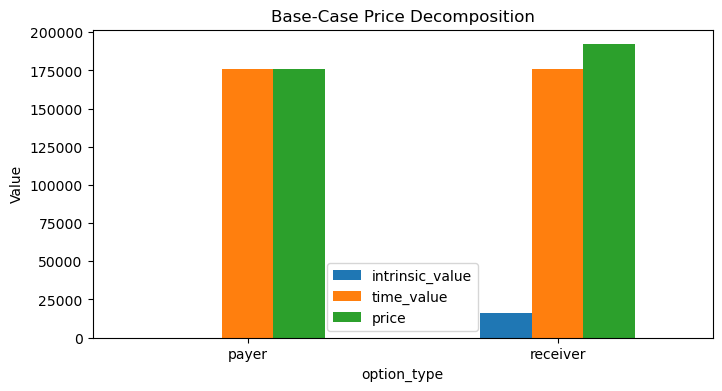

In [6]:
ax = base_decomp_df.plot(x='option_type', y=['intrinsic_value', 'time_value', 'price'], kind='bar', figsize=(8, 4), title='Base-Case Price Decomposition')
ax.set_ylabel('Value')
plt.xticks(rotation=0)
plt.show()

## 5. Black Greeks for the Base Case

For Milestone 2, we use finite-difference sensitivities:

- `PV01`: price sensitivity to a small parallel rate move
- `Vega`: price sensitivity to a small volatility move
- `Theta`: price change from one trading day of time decay

These Greeks turn the pricing engine into a usable first-pass risk tool.

In [7]:
payer_risk = calculate_risk(curve, base_payer_spec, base_vol)
receiver_risk = calculate_risk(curve, base_receiver_spec, base_vol)

greeks_df = pd.DataFrame([
    {
        'option_type': 'payer',
        'pv01': payer_risk.pv01,
        'vega': payer_risk.vega,
        'theta': payer_risk.theta,
    },
    {
        'option_type': 'receiver',
        'pv01': receiver_risk.pv01,
        'vega': receiver_risk.vega,
        'theta': receiver_risk.theta,
    },
])
greeks_df

,option_type,pv01,vega,theta
0,payer,-2230.032332,912612.860369,-133.711317
1,receiver,2049.609201,912612.860369,-169.142887


## 6. Payer Moneyness: ATM, ITM, and OTM

For a payer swaption:

- lower strike means more in the money
- strike close to the forward is near the money
- higher strike means more out of the money

In [8]:
strike_cases = [0.0350, 0.0400, 0.0450]
payer_rows = []

for strike in strike_cases:
    spec = SwaptionSpec(
        notional=base_payer_spec.notional,
        expiry=base_payer_spec.expiry,
        tenor=base_payer_spec.tenor,
        strike=strike,
        pay_frequency=base_payer_spec.pay_frequency,
        option_type='payer',
    )
    payer_rows.append({
        'strike': strike,
        'moneyness_label': moneyness_label(curve, spec, tolerance=0.0010),
        'intrinsic_value': intrinsic_value(curve, spec),
        'time_value': time_value(curve, spec, base_vol),
        'price': price_swaption(curve, spec, base_vol),
    })

payer_moneyness_df = pd.DataFrame(payer_rows)
payer_moneyness_df

,strike,moneyness_label,intrinsic_value,time_value,price
0,0.035,ITM,189125.591114,93809.697981,282935.289095
1,0.040,ATM,0.000000,175849.684472,175849.684472
2,0.045,OTM,0.000000,104027.063412,104027.063412


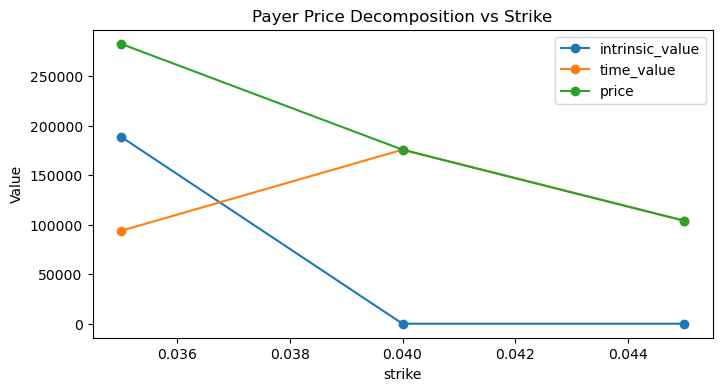

In [9]:
ax = payer_moneyness_df.plot(x='strike', y=['intrinsic_value', 'time_value', 'price'], marker='o', figsize=(8, 4), title='Payer Price Decomposition vs Strike')
ax.set_ylabel('Value')
plt.show()

## 7. Receiver Swaption Analysis

For a receiver swaption, the strike sensitivity runs in the opposite direction. A higher strike makes the right to receive fixed more attractive.

In [10]:
receiver_rows = []

for strike in strike_cases:
    spec = SwaptionSpec(
        notional=base_receiver_spec.notional,
        expiry=base_receiver_spec.expiry,
        tenor=base_receiver_spec.tenor,
        strike=strike,
        pay_frequency=base_receiver_spec.pay_frequency,
        option_type='receiver',
    )
    receiver_rows.append({
        'strike': strike,
        'moneyness_label': moneyness_label(curve, spec, tolerance=0.0010),
        'intrinsic_value': intrinsic_value(curve, spec),
        'time_value': time_value(curve, spec, base_vol),
        'price': price_swaption(curve, spec, base_vol),
    })

receiver_moneyness_df = pd.DataFrame(receiver_rows)
receiver_moneyness_df

,strike,moneyness_label,intrinsic_value,time_value,price
0,0.035,OTM,0.000000,93809.697981,93809.697981
1,0.040,ATM,16246.016795,175849.684472,192095.701267
2,0.045,ITM,221617.624704,104027.063412,325644.688116


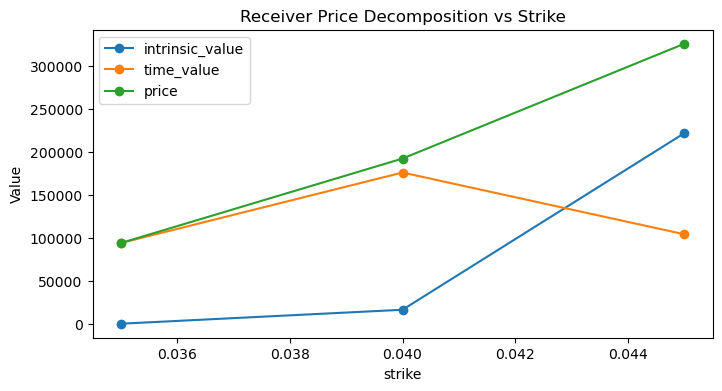

In [11]:
ax = receiver_moneyness_df.plot(x='strike', y=['intrinsic_value', 'time_value', 'price'], marker='o', figsize=(8, 4), title='Receiver Price Decomposition vs Strike')
ax.set_ylabel('Value')
plt.show()

## 8. Volatility Sensitivity

A higher Black volatility should increase option value because it increases the dispersion of future swap rates. Intrinsic value stays fixed under a volatility sweep; time value carries the effect.

In [12]:
vols = [0.10, 0.15, 0.20, 0.25, 0.30]
vol_df = pd.DataFrame([
    {
        'vol': vol,
        'payer_price': price_swaption(curve, base_payer_spec, vol),
        'payer_time_value': time_value(curve, base_payer_spec, vol),
        'receiver_price': price_swaption(curve, base_receiver_spec, vol),
        'receiver_time_value': time_value(curve, base_receiver_spec, vol),
    }
    for vol in vols
])
vol_df

,vol,payer_price,payer_time_value,receiver_price,receiver_time_value
0,0.10,84263.760166,84263.760166,100509.776961,84263.760166
1,0.15,130123.730467,130123.730467,146369.747262,130123.730467
2,0.20,175849.684472,175849.684472,192095.701267,175849.684472
3,0.25,221362.584954,221362.584954,237608.601749,221362.584954
4,0.30,266599.392564,266599.392564,282845.409359,266599.392564


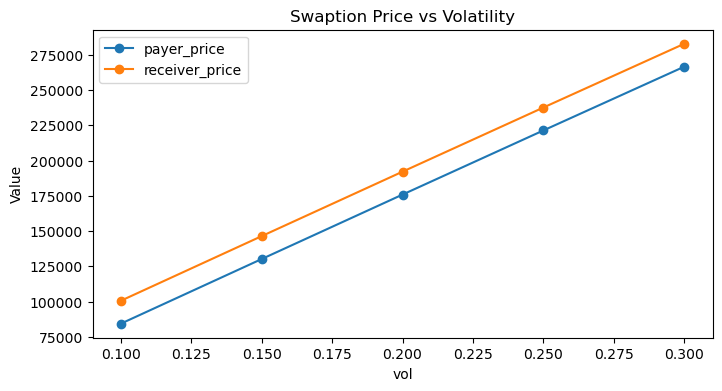

In [13]:
ax = vol_df.plot(x='vol', y=['payer_price', 'receiver_price'], marker='o', figsize=(8, 4), title='Swaption Price vs Volatility')
ax.set_ylabel('Value')
plt.show()

## 9. Expiry Sensitivity

A longer expiry often increases time value because the forward swap rate has more time to move before exercise, though the curve and annuity also move as expiry changes.

In [14]:
expiries = [1.0, 2.0, 3.0]
expiry_rows = []

for expiry in expiries:
    payer_spec = SwaptionSpec(
        notional=10_000_000.0,
        expiry=expiry,
        tenor=4.0,
        strike=0.0400,
        pay_frequency=1,
        option_type='payer',
    )
    expiry_rows.append({
        'expiry': expiry,
        'forward': forward_swap_rate(curve, payer_spec.expiry, payer_spec.tenor, payer_spec.pay_frequency),
        'annuity': swap_annuity(curve, payer_spec.expiry, payer_spec.tenor, payer_spec.pay_frequency),
        'intrinsic_value': intrinsic_value(curve, payer_spec),
        'time_value': time_value(curve, payer_spec, base_vol),
        'price': price_swaption(curve, payer_spec, base_vol),
    })

expiry_df = pd.DataFrame(expiry_rows)
expiry_df

,expiry,forward,annuity,intrinsic_value,time_value,price
0,1.0,0.040086,3.480866,3008.934985,109530.099670,112539.034655
1,2.0,0.039626,3.348192,0.000000,143729.047631,143729.047631
2,3.0,0.039512,3.220925,0.000000,168341.484091,168341.484091


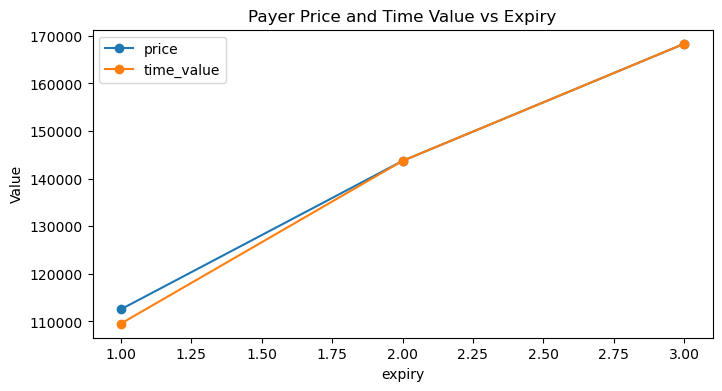

In [15]:
ax = expiry_df.plot(x='expiry', y=['price', 'time_value'], marker='o', figsize=(8, 4), title='Payer Price and Time Value vs Expiry')
ax.set_ylabel('Value')
plt.show()

## 10. Interpretation

- The Black swaption engine relies directly on Milestone 1 outputs: the forward swap rate and the swap annuity.
- The total price can be decomposed into intrinsic value and time value.
- `PV01`, `vega`, and `theta` turn the price engine into a first-pass risk engine.
- For payer swaptions, a lower strike increases intrinsic value and usually increases total price.
- For receiver swaptions, a higher strike increases intrinsic value and usually increases total price.
- Higher volatility does not change intrinsic value, but it increases time value.
- Longer expiry often increases time value, though the final result also depends on forward rate and annuity changes.

This notebook now serves as both the pricing and interpretation benchmark before moving into SABR smile modeling.